
=== ROZPOCZYNAM PEŁNĄ ANALIZĘ ===

=== ROZPOCZYNAM ŁADOWANIE DANYCH ===

Wczytuję dane cenowe z pliku: cdr_d.csv

Struktura danych cenowych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7549 entries, 0 to 7548
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Data        7549 non-null   object 
 1   Otwarcie    7549 non-null   float64
 2   Najwyzszy   7549 non-null   float64
 3   Najnizszy   7549 non-null   float64
 4   Zamkniecie  7549 non-null   float64
 5   Wolumen     7549 non-null   float64
dtypes: float64(5), object(1)
memory usage: 354.0+ KB
None

Pierwsze 5 wierszy danych cenowych:
         Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie        Wolumen
0  1994-08-02   7.84618    7.84618    7.84618     7.84618  366252.198894
1  1994-08-03   8.61783    8.61783    8.61783     8.61783  343129.905850
2  1994-08-04   9.47245    9.47245    9.47245     9.47245  375104.206490
3  1994-08-08   8.61783    8.61783  

## Analiza Raportu

**Data raportu:** 2021-01-29

### Przewidywane zmiany i rzeczywiste wyniki

,Okres,Przewidywana zmiana (%),Rzeczywista zmiana (%),Różnica (%)
0,D0,-5.0,-16.4,-11.4
1,D3,-10.0,-16.2,-6.2
2,D7,-15.0,-19.6,-4.6
3,D14,-20.0,-27.9,-7.9
4,D30,-25.0,-35.2,-10.2


### Uzasadnienie GPT

D0: -5.00%
D3: -10.00%
D7: -15.00%
D14: -20.00%
D30: -25.00%

Uzasadnienie:

- **Wpływ treści raportu**: Złożenie pozwu zbiorowego przeciwko CD PROJEKT S.A. może wywołać negatywne reakcje inwestorów, obawiających się o przyszłe wyniki finansowe spółki oraz jej reputację. Tego typu sytuacje często prowadzą do paniki na rynku, co może skutkować znacznymi spadkami cen akcji.

- **Dane historyczne**: Analizując dane historyczne, widzimy, że średnia wielkość spadku wynosi -3.38%, a maksymalny spadek wyniósł -12.22%. Jednak w obliczu tak poważnego wydarzenia, jak pozew zbiorowy, można oczekiwać, że spadki będą znacznie większe niż te historyczne, co uzasadnia prognozy na poziomie -5% w dniu otwarcia oraz -10% w ciągu trzech dni.

- **Wskaźniki techniczne**: Średnie kroczące wskazują na trend wzrostowy w dłuższym okresie, ale w obliczu negatywnych informacji, inwestorzy mogą zignorować te wskaźniki i skupić się na ryzyku związanym z pozwem. Zbliżenie się do średniej kroczącej 100-dniowej (335.33 PLN) może być trudne, a spadki mogą być bardziej wyraźne.

- **Zmienność rynku i potencjalne reakcje inwestorów**: Zmienność dzienna wynosząca 4.34% oraz 100-dniowa na poziomie 4.61% wskazują na to, że rynek CD PROJEKT S.A. jest podatny na duże wahania. W obliczu negatywnych informacji, inwestorzy mogą reagować emocjonalnie, co prowadzi do większych spadków niż te, które byłyby przewidywane na podstawie historycznych danych. W związku z tym, przewiduję, że w ciągu 30 dni cena akcji może spaść o 25%, co jest odzwierciedleniem dużej niepewności i potencjalnych dalszych negatywnych informacji.


Tworzę wykresy analizy technicznej...


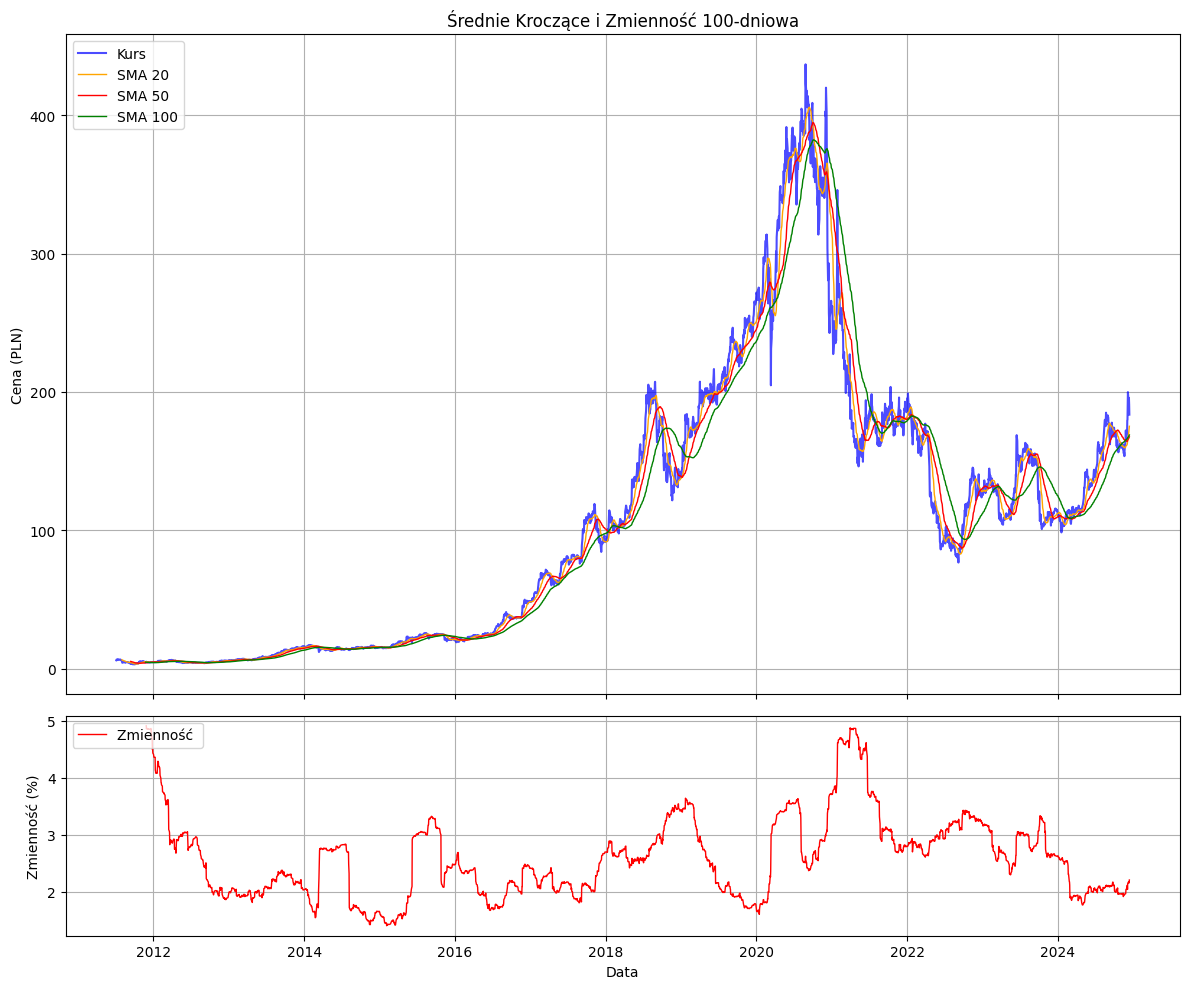


Tworzę wykresy wpływu raportu...


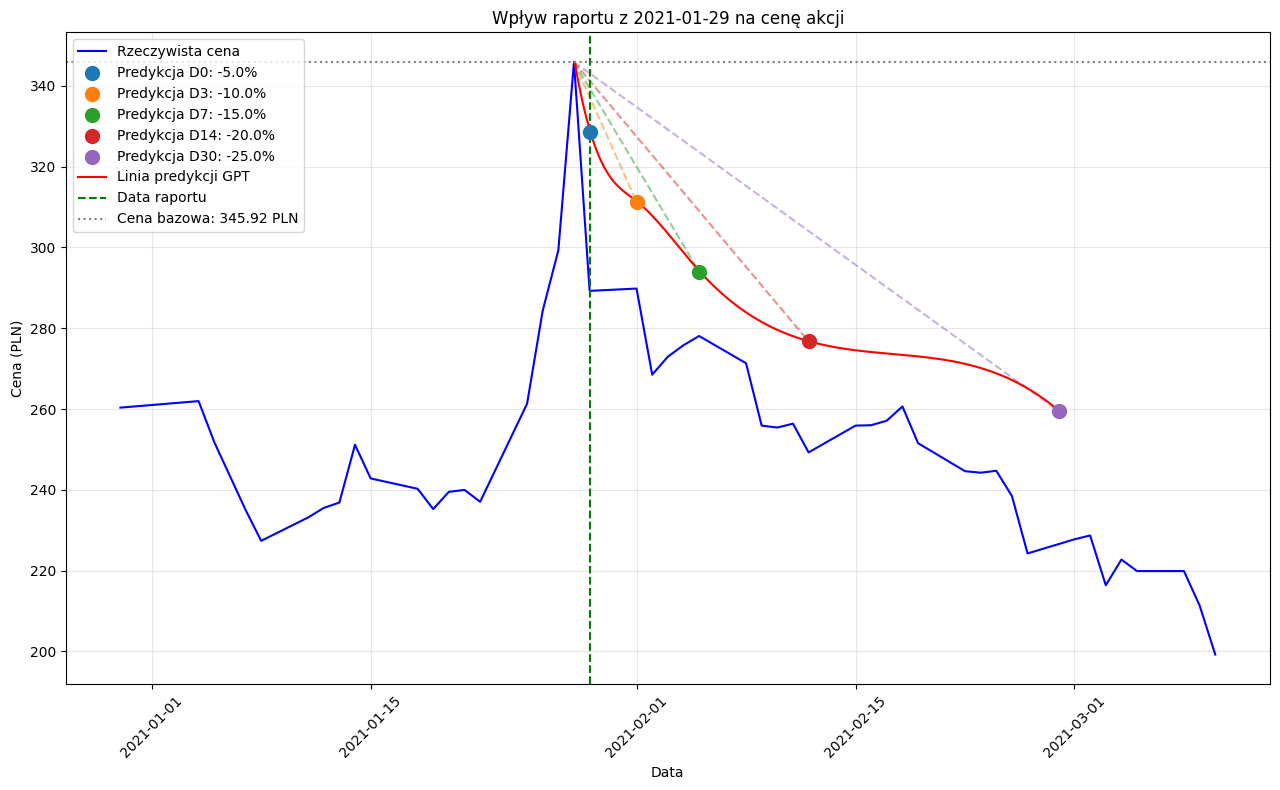


=== ANALIZA ZAKOŃCZONA ===

Wywołuję model GPT, aby stworzył pełną notatkę...

Notatka została zapisana do pliku: D:\PycharmProjects\SGH fin\full_analysis_reportcd3.md


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import re
from scipy.interpolate import interp1d
import numpy as np
import openai
from IPython.display import display, Markdown
import os

# openai.api_key = ############


def load_and_prepare_data(price_file='########.csv', reports_file='###########.csv', first_report_date='####-##-##'):
    print("\n=== ROZPOCZYNAM ŁADOWANIE DANYCH ===")

    # Wczytanie danych cenowych
    print(f"\nWczytuję dane cenowe z pliku: {price_file}")
    df_prices = pd.read_csv(price_file)
    print("\nStruktura danych cenowych:")
    print(df_prices.info())
    print("\nPierwsze 5 wierszy danych cenowych:")
    print(df_prices.head())

    # Konwersja dat
    df_prices['Data'] = pd.to_datetime(df_prices['Data'])
    print("\nPo konwersji dat - przykład formatu daty:")
    print(df_prices['Data'].iloc[0])

    # Filtrowanie danych
    df_prices = df_prices[df_prices['Data'] >= first_report_date]
    df_prices = df_prices.sort_values('Data')
    print(f"\nLiczba wierszy po filtrowaniu od {first_report_date}:")
    print(len(df_prices))

    # Wczytanie komunikatów
    print(f"\nWczytuję raporty z pliku: {reports_file}")
    df_reports = pd.read_csv(reports_file)
    df_reports['data'] = pd.to_datetime(df_reports['data'])
    df_reports = df_reports.sort_values('data')

    print("\nStruktura danych raportów:")
    print(df_reports.info())
    print("\nPierwsze 2 raporty:")
    print(df_reports[['data', 'url']].head(2))

    print("\nZakresy dat w danych:")
    print(f"Ceny: od {df_prices['Data'].min()} do {df_prices['Data'].max()}")
    print(f"Raporty: od {df_reports['data'].min()} do {df_reports['data'].max()}")

    return df_prices, df_reports


def calculate_historical_stats(df_prices, report_date, sessions=100):
    print(f"\n=== OBLICZAM STATYSTYKI HISTORYCZNE dla {sessions} dni przed {report_date} ===")
    historical_data = df_prices[df_prices['Data'] < report_date].copy()
    historical_data = historical_data.tail(sessions)

    # Wyświetl dane początkowe/końcowe dla weryfikacji
    print("\nWeryfikacja danych:")
    print(f"Początek okresu: {historical_data['Data'].iloc[0]}, cena: {historical_data['Zamkniecie'].iloc[0]:.2f}")
    print(f"Koniec okresu: {historical_data['Data'].iloc[-1]}, cena: {historical_data['Zamkniecie'].iloc[-1]:.2f}")

    # DZIENNE zmiany procentowe
    historical_data['zmiana%'] = historical_data['Zamkniecie'].pct_change() * 100
    dzienne_zmiany = historical_data['zmiana%'].dropna()

    print("\nAnaliza dziennych zmian:")
    print(f"Liczba dni z danymi: {len(dzienne_zmiany)}")
    print(f"Pierwsze 5 zmian dziennych:")
    for i, (data, zmiana) in enumerate(zip(historical_data['Data'].iloc[1:6], dzienne_zmiany.iloc[0:5])):
        print(f"{data.strftime('%Y-%m-%d')}: {zmiana:+.2f}%")

    stats = {
        'avg_gain': dzienne_zmiany[dzienne_zmiany > 0].mean(),  # średnia wzrostów
        'avg_loss': dzienne_zmiany[dzienne_zmiany < 0].mean(),  # średnia spadków
        'max_gain': dzienne_zmiany.max(),
        'max_loss': dzienne_zmiany.min(),
        'volatility': dzienne_zmiany.std(),
        'up_days_pct': len(dzienne_zmiany[dzienne_zmiany > 0]) / len(dzienne_zmiany) * 100  # procent dni wzrostowych
    }

    print("\nDodatkowe statystyki:")
    print(
        f"Zmiana całkowita w okresie: {((historical_data['Zamkniecie'].iloc[-1] / historical_data['Zamkniecie'].iloc[0]) - 1) * 100:.2f}%")
    print(
        f"Dni wzrostowe: {len(dzienne_zmiany[dzienne_zmiany > 0])} ({len(dzienne_zmiany[dzienne_zmiany > 0]) / len(dzienne_zmiany) * 100:.1f}%)")
    print(
        f"Dni spadkowe: {len(dzienne_zmiany[dzienne_zmiany < 0])} ({len(dzienne_zmiany[dzienne_zmiany < 0]) / len(dzienne_zmiany) * 100:.1f}%)")
    print(f"Średnia wzrostów: {dzienne_zmiany[dzienne_zmiany > 0].mean():.2f}%")
    print(f"Średnia spadków: {dzienne_zmiany[dzienne_zmiany < 0].mean():.2f}%")

    return stats


def calculate_technical_indicators(df_prices, report_date):
    print("\n=== OBLICZAM WSKAŹNIKI TECHNICZNE ===")

    df = df_prices[df_prices['Data'] <= report_date].copy()

    # Średnie kroczące
    df_prices['SMA_5'] = df_prices['Zamkniecie'].rolling(window=5, min_periods=5).mean()
    df_prices['SMA_10'] = df_prices['Zamkniecie'].rolling(window=10, min_periods=10).mean()
    df_prices['SMA_20'] = df_prices['Zamkniecie'].rolling(window=20, min_periods=20).mean()
    df_prices['SMA_50'] = df_prices['Zamkniecie'].rolling(window=50, min_periods=50).mean()
    df_prices['SMA_100'] = df_prices['Zamkniecie'].rolling(window=100, min_periods=100).mean()

    # Obliczanie zmienności
    daily_returns = df['Zamkniecie'].pct_change()

    window = 100
    df['Volatility'] = (
            daily_returns
            .rolling(window=window, min_periods=100)
            .std()
            * 100
    )

    # 3 dni przed raportem dla logowania
    last_3_days = df.tail(3)
    print("\nOstatnie 3 dni przed raportem:")
    print(last_3_days[['Data', 'Zamkniecie', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100']])

    print("\nWartości zmienności (ostatnie 3 dni):")
    print(last_3_days[['Data', 'Volatility']])

    return df.iloc[-1]


def visualize_data(df_prices):
    """Generuje wykresy dla analizy"""

    # górny dla SMA, dolny dla zmienności
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(df_prices['Data'], df_prices['Zamkniecie'], label="Kurs", color="blue", alpha=0.7)
    # Górny wykres: Średnie kroczące
    ax1.plot(df_prices['Data'], df_prices['SMA_20'], label="SMA 20", color="orange", linewidth=1)
    ax1.plot(df_prices['Data'], df_prices['SMA_50'], label="SMA 50", color="red", linewidth=1)
    ax1.plot(df_prices['Data'], df_prices['SMA_100'], label="SMA 100", color="green", linewidth=1)


    ax1.set_ylabel("Cena (PLN)")
    ax1.set_title("Średnie Kroczące i Zmienność 100-dniowa")
    ax1.legend(loc="upper left")
    ax1.grid(True)


    ax2.plot(df_prices['Data'], df_prices['Volatility'], label="Zmienność ", color="red", linewidth=1)
    ax2.set_ylabel("Zmienność (%)")
    ax2.set_xlabel("Data")
    ax2.grid(True)
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

def create_gpt_prompt(report_date, report_content, base_price, historical_stats, technical_stats):
    print("\n=== TWORZĘ PROMPT DLA GPT ===")

    technical_stats_str = (
        f"Średnia krocząca (5-dniowa): {technical_stats['SMA_5']:.2f}\n"
        f"Średnia krocząca (10-dniowa): {technical_stats['SMA_10']:.2f}\n"
        f"Średnia krocząca (20-dniowa): {technical_stats['SMA_20']:.2f}\n"
        f"Średnia krocząca (50-dniowa): {technical_stats['SMA_50']:.2f}\n"
        f"Średnia krocząca (100-dniowa): {technical_stats['SMA_100']:.2f}\n"
        f"Zmienność 100-dniowa: {technical_stats['Volatility']:.2f}%"
    )
    prompt = f"""WAŻNE: Znajdujesz się PRZED otwarciem rynku w dniu {report_date.strftime('%Y-%m-%d')}. 
    Ogranicz swój zasób wiedzy do dnia {report_date.strftime('%Y-%m-%d')}. Otrzymano komunikat giełdowy, którego treść znajduje się poniżej. 

    Twoim zadaniem jest przewidzieć konkretne zmiany procentowe ceny akcji w różnych horyzontach czasowych. 
    **Nie bądź zachowawczy. Uwzględnij dużą zmienność rynku i generuj prognozy odważnie.**  
    Prognozy mogą obejmować wartości w zakresie wyższym niż historyczne maksymalne wzrosty i spadki.

    Uwzględnij:
    1. **Wysoką zmienność rynku**: Weź pod uwagę, że ceny mogą się gwałtownie zmieniać. Nie ograniczaj się do małych wartości procentowych.
    2. **Trend historyczny i dane techniczne**: Zwróć szczególną uwagę na ostatnie wzrosty, spadki oraz zmienność dzienną.
    3. **Sentyment rynkowy**: Rozważ wpływ raportu na nastroje inwestorów i potencjalne reakcje rynku.
    4. **Znaczące odchylenia**: Nie bój się sugerować większych zmian procentowych, jeśli dane na to wskazują.
    5. **Twoja analiza ma być dynamiczna**: Przedstaw konkretne przewidywania oparte na danych historycznych i raportowych.

    Raport:
    {report_content}

    Cena zamknięcia z poprzedniego dnia: {base_price:.2f} PLN

    Historyczne dane (ostatnie 100 sesji):
    - Procent dni wzrostowych: {historical_stats['up_days_pct']:.1f}%
    - Średnia wielkość wzrostu: {historical_stats['avg_gain']:.2f}%
    - Średnia wielkość spadku: {historical_stats['avg_loss']:.2f}%
    - Maksymalny wzrost: {historical_stats['max_gain']:.2f}% 
    - Maksymalny spadek: {historical_stats['max_loss']:.2f}% 
    - Zmienność dzienna: {historical_stats['volatility']:.2f}%

    Wskaźniki techniczne:
    {technical_stats_str}

    WYMAGANY FORMAT ODPOWIEDZI:
    1. Najpierw podaj konkretne przewidywania w następującym formacie (TYLKO LICZBY, BEZ DODATKOWEGO TEKSTU):
    D0: [liczba]%
    D3: [liczba]%
    D7: [liczba]%
    D14: [liczba]%
    D30: [liczba]%

    2. Następnie podaj uzasadnienie swoich prognoz, analizując:
    - Wpływ treści raportu
    - Dane historyczne
    - Wskaźniki techniczne
    - Zmienność rynku i potencjalne reakcje inwestorów.
    """

    print("\nWygenerowany prompt dla GPT:")

    return prompt

def create_summary_table(gpt_predictions, actual_changes):
    periods = ['D0', 'D3', 'D7', 'D14', 'D30']
    data = []

    for period in periods:
        pred_value = gpt_predictions.get(period)
        actual_value = actual_changes.get(period)

        row = {
            "Okres": period,
            "Przewidywana zmiana (%)": f"{pred_value:.1f}" if pred_value is not None else "N/A",
            "Rzeczywista zmiana (%)": f"{actual_value:.1f}" if actual_value is not None else "N/A",
            "Różnica (%)": f"{(actual_value - pred_value):.1f}" if (
                    pred_value is not None and actual_value is not None) else "N/A"
        }
        data.append(row)

    return pd.DataFrame(data)

def analyze_report(df_prices, df_reports, report_url):
    print("\n=== ROZPOCZYNAM ANALIZĘ RAPORTU ===")
    print(f"Analizuję raport: {report_url}")

    # Znajdź raport
    report = df_reports[df_reports['url'] == report_url].iloc[0]
    report_date = report['data']
    print(f"\nData raportu: {report_date}")

    # Znajdź cenę bazową
    base_price = df_prices[df_prices['Data'] < report_date]['Zamkniecie'].iloc[-1]
    print(f"Cena bazowa (przed raportem): {base_price:.2f} PLN")

    # Oblicz statystyki
    historical_stats = calculate_historical_stats(df_prices, report_date)
    technical_stats = calculate_technical_indicators(df_prices, report_date)

    # Generuj prompt i wywołaj GPT
    prompt = create_gpt_prompt(report_date, report['tresc'], base_price, historical_stats, technical_stats)

    try:
        print("\nWywołuję model GPT...")
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system",
                 "content": """Korzystając ze swojej wiedzy, wejdź w rolę doświadczonego analityka giełdowego specjalizującego się w prognozowaniu rynku. Generuj dynamiczne prognozy oparte na danych i raporcie."""},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1
        )
        prediction = response.choices[0].message.content
        print("\nOtrzymano odpowiedź od GPT:")
        print(prediction)
    except Exception as e:
        prediction = f"Błąd GPT: {str(e)}"
        print(f"\nWYSTĄPIŁ BŁĄD GPT: {str(e)}")

    print("\nPrzetwarzam przewidywania GPT...")
    gpt_predictions = {}

    matches = re.findall(r"(D\d+).{0,20}?([+-]?\d+(?:\.\d+)?)%", prediction)
    for period, value in matches:
        gpt_predictions[period] = float(value)
        print(f"Znaleziono przewidywanie: {period} = {float(value):.2f}%")

    print("\nObliczam rzeczywiste zmiany...")
    actual_changes = {}
    for days, period in [(0, 'D0'), (3, 'D3'), (7, 'D7'), (14, 'D14'), (30, 'D30')]:
        future_date = report_date + timedelta(days=days)
        future_data = df_prices[df_prices['Data'] <= future_date]
        if not future_data.empty:
            future_price = future_data['Zamkniecie'].iloc[-1]
            change = ((future_price - base_price) / base_price) * 100
            actual_changes[period] = change
            print(f"{period} ({days} dni): {change:.2f}% (cena: {future_price:.2f} PLN)")

    # dane do wyświetlenia
    print("\nPrzygotowuję tabelę wyników...")
    periods = ['D0', 'D3', 'D7', 'D14', 'D30']
    changes_data = []

    for period in periods:
        pred_value = gpt_predictions.get(period)
        actual_value = actual_changes.get(period)

        changes_data.append({
            "Okres": period,
            "Przewidywana zmiana (%)": pred_value,
            "Rzeczywista zmiana (%)": actual_value,
            "Różnica (%)": None if pred_value is None else actual_value - pred_value
        })

    df = pd.DataFrame(changes_data)
    for col in ["Przewidywana zmiana (%)", "Rzeczywista zmiana (%)", "Różnica (%)"]:
        df[col] = df[col].apply(lambda x: f"{x:.1f}" if pd.notnull(x) else "N/A")

    display(Markdown("## Analiza Raportu"))
    display(Markdown(f"**Data raportu:** {report_date.strftime('%Y-%m-%d')}"))

    display(Markdown("### Przewidywane zmiany i rzeczywiste wyniki"))
    display(df)
    display(Markdown("### Uzasadnienie GPT"))
    display(Markdown(f"{prediction}"))

    return {
        'url': report_url,
        'data': report_date,
        'tresc_raportu': report['tresc'],
        'cena_bazowa': base_price,
        'przewidywania_gpt': gpt_predictions,
        'rzeczywiste_zmiany': actual_changes,
        'uzasadnienie': prediction,
        'historical_stats': historical_stats,
        'technical_stats': technical_stats
    }


def plot_price_impact_combined(df_prices, report_date, base_price, gpt_predictions):

    start_date = report_date - timedelta(days=30)
    end_date = report_date + timedelta(days=40)

    plot_data = df_prices[
        (df_prices['Data'] >= start_date) &
        (df_prices['Data'] <= end_date)
    ]

    plt.figure(figsize=(15, 8))

    plt.plot(plot_data['Data'], plot_data['Zamkniecie'],
             color='blue', label='Rzeczywista cena')

    base_date = df_prices[df_prices['Data'] < report_date]['Data'].iloc[-1]

    days_list = [0, 3, 7, 14, 30]
    pred_dates = [base_date]
    pred_prices = [base_price]

    colors = {
        'D0': '#1f77b4', 'D3': '#ff7f0e', 'D7': '#2ca02c',
        'D14': '#d62728', 'D30': '#9467bd'
    }

    # Zbierz punkty predykcji i narysuj punkty
    for days in days_list:
        period = f'D{days}'
        if period in gpt_predictions:
            pred_date = report_date + timedelta(days=days)
            if pred_date <= end_date:
                pred_change = gpt_predictions[period]
                pred_price = base_price * (1 + pred_change / 100)
                
                if days > 0:  
                    plt.plot([base_date, pred_date], [base_price, pred_price],
                            color=colors.get(period, '#000000'), 
                            linestyle='--', 
                            alpha=0.5)
                
                plt.scatter(pred_date, pred_price,
                          color=colors.get(period, '#000000'),
                          s=100,
                          zorder=5,
                          label=f'Predykcja {period}: {pred_change:.1f}%')
                
                pred_dates.append(pred_date)
                pred_prices.append(pred_price)


    if len(pred_dates) > 2:  # Potrzebujemy co najmniej 3 punktów dla dobrej interpolacji
        # Konwertuj daty na liczby (timestamps) dla interpolacji
        dates_num = [pd.Timestamp(date).timestamp() for date in pred_dates]
        
        # Stwórz funkcję interpolującą
        f = interp1d(dates_num, pred_prices, kind='cubic')
        
        # Stwórz więcej punktów dla płynnej linii
        x_new = np.linspace(min(dates_num), max(dates_num), 200)
        y_new = f(x_new)
        
        # Konwertuj timestamps z powrotem na daty
        x_dates = [pd.Timestamp.fromtimestamp(x) for x in x_new]
        
        # Narysuj wygładzoną linię
        plt.plot(x_dates, y_new,
                color='red', linestyle='-',
                label='Linia predykcji GPT',
                alpha=1)

    plt.axvline(x=report_date, color='green', linestyle='--',
                label='Data raportu')
    plt.axhline(y=base_price, color='gray', linestyle=':',
                label=f'Cena bazowa: {base_price:.2f} PLN')

    plt.title(f'Wpływ raportu z {report_date.strftime("%Y-%m-%d")} na cenę akcji')
    plt.xlabel('Data')
    plt.ylabel('Cena (PLN)')
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

# Przykład użycia
print("\n=== ROZPOCZYNAM PEŁNĄ ANALIZĘ ===")
df_prices, df_reports = load_and_prepare_data()

df_prices['SMA_5'] = df_prices['Zamkniecie'].rolling(5, closed='left').mean()
df_prices['SMA_10'] = df_prices['Zamkniecie'].rolling(10, closed='left').mean()
df_prices['SMA_20'] = df_prices['Zamkniecie'].rolling(20, closed='left').mean()
df_prices['SMA_50'] = df_prices['Zamkniecie'].rolling(50, closed='left').mean()
df_prices['SMA_100'] = df_prices['Zamkniecie'].rolling(100, closed='left').mean()
daily_returns = df_prices['Zamkniecie'].pct_change()
df_prices['Volatility'] = daily_returns.rolling(window=100, min_periods=100).std() * 100

print("\nAnalizuję przykładowy raport...")
url = "https://espiebi.pap.pl/node/468510"
result = analyze_report(df_prices, df_reports, url)

print("\nTworzę wykresy analizy technicznej...")
visualize_data(df_prices)

print("\nTworzę wykresy wpływu raportu...")

plot_price_impact_combined(df_prices, result['data'], result['cena_bazowa'],
                         result['przewidywania_gpt'])

print("\n=== ANALIZA ZAKOŃCZONA ===")

def generate_full_analysis_summary(result, gpt_predictions, actual_changes, historical_stats, technical_stats, filename="full_analysis_report.md"):

    comparison_table = "| Okres | Przewidywana zmiana (%) | Rzeczywista zmiana (%) | Różnica (%) |\n"
    comparison_table += "|-------|--------------------------|------------------------|-------------|\n"
    for period in ['D0', 'D3', 'D7', 'D14', 'D30']:
        pred_value = gpt_predictions.get(period, "N/A")
        actual_value = actual_changes.get(period, "N/A")
        if pred_value != "N/A" and actual_value != "N/A":
            difference = actual_value - pred_value
            comparison_table += f"| {period} | {pred_value:.1f} | {actual_value:.1f} | {difference:.1f} |\n"
        else:
            comparison_table += f"| {period} | N/A | N/A | N/A |\n"

    # Zbieranie wszystkich danych
    input_data = f"""
    ### Szczegóły raportu
    - **Data raportu**: {result['data'].strftime('%Y-%m-%d')}
    - **Cena bazowa**: {result['cena_bazowa']:.2f} PLN
    - **Źródło raportu**: {result['url']}

    ### Tabela porównawcza wyników
    {comparison_table}

    ### Statystyki historyczne (100 sesji)
    - Procent dni wzrostowych: {historical_stats['up_days_pct']:.1f}%
    - Średnia wielkość wzrostu: {historical_stats['avg_gain']:.2f}%
    - Średnia wielkość spadku: {historical_stats['avg_loss']:.2f}%
    - Maksymalny wzrost: {historical_stats['max_gain']:.2f}%
    - Maksymalny spadek: {historical_stats['max_loss']:.2f}%
    - Zmienność dzienna: {historical_stats['volatility']:.2f}%

    ### Wskaźniki techniczne (na dzień {result['data'].strftime('%Y-%m-%d')})
    - Średnia krocząca 20-dniowa (SMA_20): {technical_stats['SMA_20']:.2f}
    - Średnia krocząca 50-dniowa (SMA_50): {technical_stats['SMA_50']:.2f}
    - Zmienność 100-dniowa: {technical_stats['Volatility']:.2f}%
    """

    prompt = f"""
    Twoim zadaniem jest stworzenie pełnej notatki na temat poniższej analizy prognoz kursu akcji.

    ### Dane analizy:
    {input_data}

    ### Zasady tworzenia notatki:
    1. **Podsumuj kluczowe wnioski** w czytelny sposób.
    2. Wskaż **dokładność prognoz modelu AI** w różnych horyzontach czasowych.
    3. Wymień **największe zgodności** i **największe odchylenia**.
    4. Zinterpretuj **statystyki historyczne** i **wskaźniki techniczne**.
    5. Przenalizuj **wnioski i rekomendacje** względem rzeczywistych wyników i przygotuj notatkę podsumowująca wyniki predykcji z wykorzystaniem sztucznej inteligencji.
    Format odpowiedzi: **czytelny i formalny Markdown** z nagłówkami, punktami i listami.
    """

    try:
        print("\nWywołuję model GPT, aby stworzył pełną notatkę...")
        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "Jesteś analitykiem finansowym specjalizującym się w prognozowaniu rynku i pisaniu raportów."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3
        )
        gpt_note = response.choices[0].message.content

        with open(filename, "w", encoding="utf-8") as file:
            file.write(gpt_note)
        print(f"\nNotatka została zapisana do pliku: {os.path.abspath(filename)}")
    except Exception as e:
        print(f"Wystąpił błąd: {str(e)}")

generate_full_analysis_summary(
    result=result,
    gpt_predictions=result['przewidywania_gpt'],
    actual_changes=result['rzeczywiste_zmiany'],
    historical_stats=result['historical_stats'],
    technical_stats=result['technical_stats'],
    filename="full_analysis_report.md"
)